In [11]:
from resources.imports import *
from openpyxl import load_workbook

# Material Models

In [12]:
MAT = "Ti"

material_df = pd.read_csv(f"Z:/p1/MaterialModels/{MAT}/strut-StressStrain.csv", header=None, names=['strain', 'stress'])
literature_df = pd.read_csv(f"Z:/p1/MaterialModels/{MAT}/strut-literature.csv", header=None, names=['strain', 'stress'])

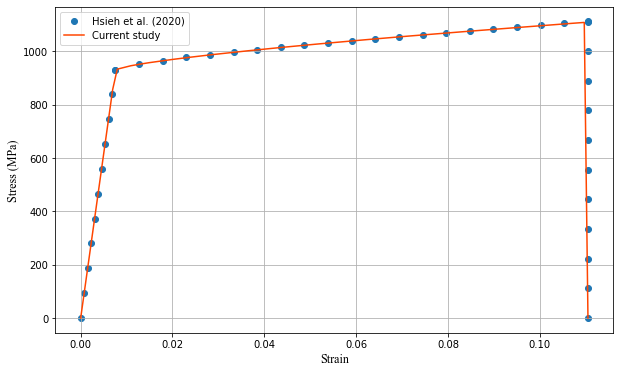

In [13]:
fig0, (ax1) = plt.subplots(1, 1)
fig0.set_figheight(6)
fig0.set_figwidth(10)

ax1.set_ylabel('Stress (MPa)', fontsize=12, fontname="Times New Roman")
ax1.set_xlabel('Strain', fontsize=12, fontname="Times New Roman")
if MAT == "Ti":
    ax1.scatter(literature_df.strain.tolist(), literature_df.stress.tolist(), label='Hsieh et al. (2020)')
elif MAT == "SiC":
    ax1.scatter(literature_df.strain.tolist(), literature_df.stress.tolist(), label='Hsieh et al. (2020)')
elif MAT == "Al":
    ax1.scatter(literature_df.strain.tolist(), literature_df.stress.tolist(), label='Gu et al. (2018)')
    
ax1.plot(material_df.strain.tolist(), material_df.stress.tolist(), c='orangered', label='Current study')

ax1.grid()
ax1.legend()

# Convergence & Validation Studies

## Perfect Size Convergence Study

In [18]:
researchData = "C:/Users/exy053/OneDrive - Queen Mary, University of London/Documents/Research/p1-LatticeFractureToughness/Ductility-FractureToughness.xlsx"

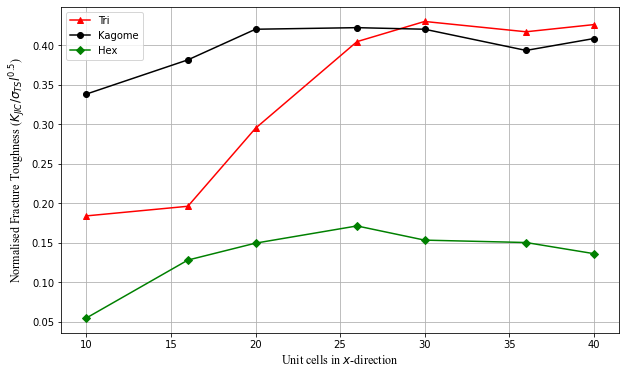

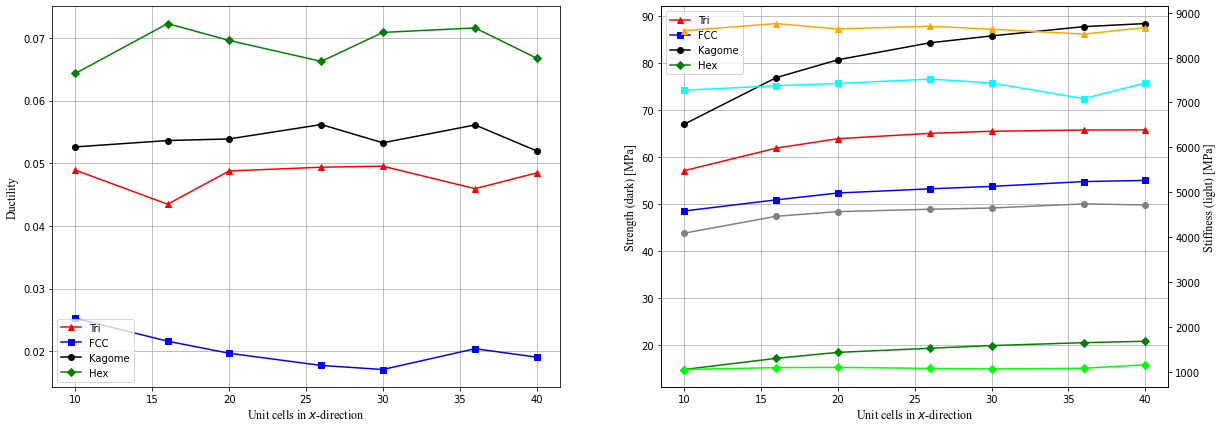

In [37]:
PerSizeConv_df = pd.read_excel(researchData, sheet_name="PSC4", header=25)

drop_cols = [i for i in PerSizeConv_df.columns if "Unnamed" in i]
PerSizeConv_df = PerSizeConv_df.drop(columns=drop_cols)

tri_PSCdf = PerSizeConv_df[PerSizeConv_df.lat == "tri"].reset_index(drop=True)
tri3_PSCdf = tri_PSCdf[tri_PSCdf.strut_l == 0.003]
tri10_PSCdf = tri_PSCdf[tri_PSCdf.strut_l == 0.01]

FCC_PSCdf = PerSizeConv_df[PerSizeConv_df.lat == "FCC"].reset_index(drop=True)
FCC3_PSCdf = FCC_PSCdf[FCC_PSCdf.strut_l == 0.003]
FCC10_PSCdf = FCC_PSCdf[FCC_PSCdf.strut_l == 0.01]

kagome_PSCdf = PerSizeConv_df[PerSizeConv_df.lat == "kagome"].reset_index(drop=True)
kagome3_PSCdf = kagome_PSCdf[kagome_PSCdf.strut_l == 0.003]
kagome10_PSCdf = kagome_PSCdf[kagome_PSCdf.strut_l == 0.01]

hex_PSCdf = PerSizeConv_df[PerSizeConv_df.lat == "hex"].reset_index(drop=True)
hex3_PSCdf = hex_PSCdf[hex_PSCdf.strut_l == 0.003]
hex10_PSCdf = hex_PSCdf[hex_PSCdf.strut_l == 0.01]

fig1, (ax1) = plt.subplots(1, 1)
fig1.set_figheight(6)
fig1.set_figwidth(10)
#fig1.suptitle("Perfect Latice Size Convergence Study", fontsize=16, fontname="Times New Roman", fontweight='bold')

#ax1.set_title("Fracture Toughness", fontsize=14, fontname="Times New Roman", fontweight='bold')
ax1.set_ylabel('Normalised Fracture Toughness ($K_{JIC}/\sigma_{TS}l^{0.5}$)', fontsize=12, fontname="Times New Roman")
ax1.set_xlabel('Unit cells in $x$-direction', fontsize=12, fontname="Times New Roman")

# ax1.plot(tri3_PSCdf["nnx"].tolist(), tri3_PSCdf["Kj1c/Sts*root_l"].tolist(), "^-", c="orange", label="tri 3mm")
ax1.plot(tri10_PSCdf["nnx"].tolist(), tri10_PSCdf["Kj1c/Sts*root_l"].tolist(), "^-", c="red", label="Tri")

# ax1.plot(kagome3_PSCdf["nnx"].tolist(), kagome3_PSCdf["Kj1c/Sts*root_l"].tolist(), "o-", c="gray", label="kagome 3mm")
ax1.plot(kagome10_PSCdf["nnx"].tolist(), kagome10_PSCdf["Kj1c/Sts*root_l"].tolist(), "o-", c="black", label="Kagome")

# ax1.plot(hex3_PSCdf["nnx"].tolist(), hex3_PSCdf["Kj1c/Sts*root_l"].tolist(), "D-", c="limegreen", label="hex 3mm")
ax1.plot(hex10_PSCdf["nnx"].tolist(), hex10_PSCdf["Kj1c/Sts*root_l"].tolist(), "D-", c="green", label="Hex")

ax1.grid()
ax1.legend()#bbox_to_anchor=(0.981,1))
plt.show()


fig2, (ax2, ax3) = plt.subplots(1, 2)
fig2.set_figheight(7)
fig2.set_figwidth(20)

#ax2.set_title("Ductility", fontsize=14, fontname="Times New Roman", fontweight='bold')
ax2.set_ylabel('Ductility', fontsize=12, fontname="Times New Roman")
ax2.set_xlabel('Unit cells in $x$-direction', fontsize=12, fontname="Times New Roman")

ax2.plot(tri10_PSCdf.loc[tri10_PSCdf["e"].dropna().index]["nnx"].tolist(), 
         tri10_PSCdf.loc[tri10_PSCdf["e"].dropna().index]["e"].tolist(), "r^-", label="Tri")

ax2.plot(FCC10_PSCdf.loc[FCC10_PSCdf["e"].dropna().index]["nnx"].tolist(), 
         FCC10_PSCdf.loc[FCC10_PSCdf["e"].dropna().index]["e"].tolist(), "bs-", label="FCC")

ax2.plot(kagome10_PSCdf.loc[kagome10_PSCdf["e"].dropna().index]["nnx"].tolist(), 
         kagome10_PSCdf.loc[kagome10_PSCdf["e"].dropna().index]["e"].tolist(), "ko-", label="Kagome")

ax2.plot(hex10_PSCdf.loc[hex10_PSCdf["e"].dropna().index]["nnx"].tolist(), 
         hex10_PSCdf.loc[hex10_PSCdf["e"].dropna().index]["e"].tolist(), "gD-", label="Hex")

ax2.grid()
ax2.legend()


#ax3.set_title("Strength & Stiffness", fontsize=14, fontname="Times New Roman", fontweight='bold')
ax3.set_ylabel('Strength (dark) [MPa]', fontsize=12, fontname="Times New Roman")
ax3.set_xlabel('Unit cells in $x$-direction', fontsize=12, fontname="Times New Roman")

ax3.plot(tri10_PSCdf.loc[tri10_PSCdf["s_max"].dropna().index]["nnx"].tolist(), 
         tri10_PSCdf.loc[tri10_PSCdf["s_max"].dropna().index]["s_max"].tolist(), "r^-", label="Tri")

ax3.plot(FCC10_PSCdf.loc[FCC10_PSCdf["s_max"].dropna().index]["nnx"].tolist(), 
         FCC10_PSCdf.loc[FCC10_PSCdf["s_max"].dropna().index]["s_max"].tolist(), "bs-", label="FCC")

ax3.plot(kagome10_PSCdf.loc[kagome10_PSCdf["s_max"].dropna().index]["nnx"].tolist(), 
         kagome10_PSCdf.loc[kagome10_PSCdf["s_max"].dropna().index]["s_max"].tolist(), "ko-", label="Kagome")

ax3.plot(hex10_PSCdf.loc[hex10_PSCdf["s_max"].dropna().index]["nnx"].tolist(), 
         hex10_PSCdf.loc[hex10_PSCdf["s_max"].dropna().index]["s_max"].tolist(), "gD-", label="Hex")

ax3_ = ax3.twinx()
ax3_.set_ylabel('Stiffness (light) [MPa]', fontsize=12, fontname="Times New Roman")

ax3_.plot(tri10_PSCdf.loc[tri10_PSCdf["stiff"].dropna().index]["nnx"].tolist(), 
         tri10_PSCdf.loc[tri10_PSCdf["stiff"].dropna().index]["stiff"].tolist(), "^-", c="orange", label="Tri")

ax3_.plot(FCC10_PSCdf.loc[FCC10_PSCdf["stiff"].dropna().index]["nnx"].tolist(), 
         FCC10_PSCdf.loc[FCC10_PSCdf["stiff"].dropna().index]["stiff"].tolist(), "s-", c="cyan", label="FCC")

ax3_.plot(kagome10_PSCdf.loc[kagome10_PSCdf["stiff"].dropna().index]["nnx"].tolist(), 
         kagome10_PSCdf.loc[kagome10_PSCdf["stiff"].dropna().index]["stiff"].tolist(), "o-", c="gray", label="Kagome")

ax3_.plot(hex10_PSCdf.loc[hex10_PSCdf["stiff"].dropna().index]["nnx"].tolist(), 
         hex10_PSCdf.loc[hex10_PSCdf["stiff"].dropna().index]["stiff"].tolist(), "D-", c="lime", label="Hex")


ax3.grid()
#ax3.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax3.legend()
plt.show()

## Mesh Refinement Convergence Study

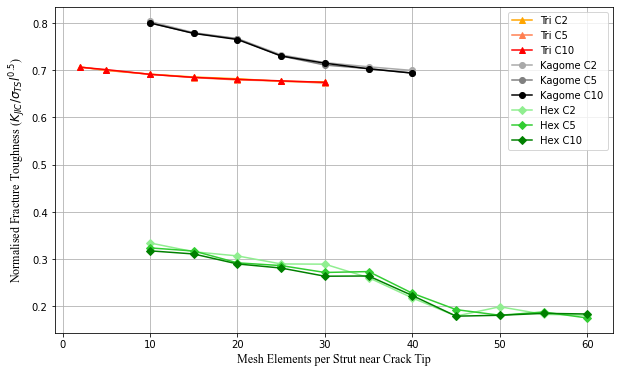

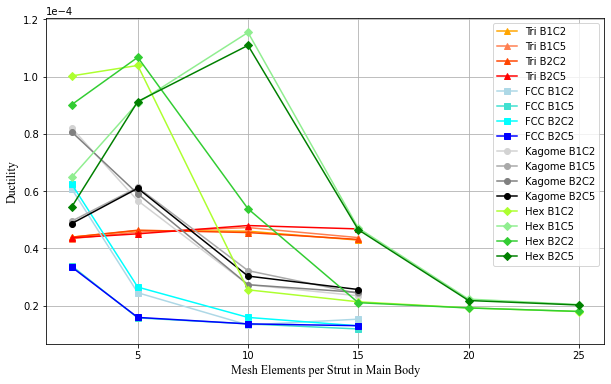

In [33]:
StrutElemConv_df = pd.read_excel(researchData, sheet_name="MeshConv", header=26)

drop_cols = [i for i in StrutElemConv_df.columns if "Unnamed" in i]
StrutElemConv_df = StrutElemConv_df.drop(columns=drop_cols)

tri_SECdf = StrutElemConv_df[StrutElemConv_df.lat == "tri"].reset_index(drop=True)
triB1C2_SECdf = tri_SECdf[tri_SECdf.brackets == 1].loc[tri_SECdf.coarse == 2]
triB1C5_SECdf = tri_SECdf[tri_SECdf.brackets == 1].loc[tri_SECdf.coarse == 5]
triB1C10_SECdf = tri_SECdf[tri_SECdf.brackets == 1].loc[tri_SECdf.coarse == 10]
triB2C2_SECdf = tri_SECdf[tri_SECdf.brackets == 2].loc[tri_SECdf.coarse == 2]
triB2C5_SECdf = tri_SECdf[tri_SECdf.brackets == 2].loc[tri_SECdf.coarse == 5]
triB2C10_SECdf = tri_SECdf[tri_SECdf.brackets == 2].loc[tri_SECdf.coarse == 10]

FCC_SECdf = StrutElemConv_df[StrutElemConv_df.lat == "FCC"].reset_index(drop=True)
FCCB1C2_SECdf = FCC_SECdf[FCC_SECdf.brackets == 1].loc[FCC_SECdf.coarse == 2]
FCCB1C5_SECdf = FCC_SECdf[FCC_SECdf.brackets == 1].loc[FCC_SECdf.coarse == 5]
FCCB1C10_SECdf = FCC_SECdf[FCC_SECdf.brackets == 1].loc[FCC_SECdf.coarse == 10]
FCCB2C2_SECdf = FCC_SECdf[FCC_SECdf.brackets == 2].loc[FCC_SECdf.coarse == 2]
FCCB2C5_SECdf = FCC_SECdf[FCC_SECdf.brackets == 2].loc[FCC_SECdf.coarse == 5]
FCCB2C10_SECdf = FCC_SECdf[FCC_SECdf.brackets == 2].loc[FCC_SECdf.coarse == 10]

kagome_SECdf = StrutElemConv_df[StrutElemConv_df.lat == "kagome"].reset_index(drop=True)
kagomeB1C2_SECdf = kagome_SECdf[kagome_SECdf.brackets == 1].loc[kagome_SECdf.coarse == 2]
kagomeB1C5_SECdf = kagome_SECdf[kagome_SECdf.brackets == 1].loc[kagome_SECdf.coarse == 5]
kagomeB1C10_SECdf = kagome_SECdf[kagome_SECdf.brackets == 1].loc[kagome_SECdf.coarse == 10]
kagomeB2C2_SECdf = kagome_SECdf[kagome_SECdf.brackets == 2].loc[kagome_SECdf.coarse == 2]
kagomeB2C5_SECdf = kagome_SECdf[kagome_SECdf.brackets == 2].loc[kagome_SECdf.coarse == 5]
kagomeB2C10_SECdf = kagome_SECdf[kagome_SECdf.brackets == 2].loc[kagome_SECdf.coarse == 10]

hex_SECdf = StrutElemConv_df[StrutElemConv_df.lat == "hex"].reset_index(drop=True)
hexB1C2_SECdf = hex_SECdf[hex_SECdf.brackets == 1].loc[hex_SECdf.coarse == 2]
hexB1C5_SECdf = hex_SECdf[hex_SECdf.brackets == 1].loc[hex_SECdf.coarse == 5]
hexB1C10_SECdf = hex_SECdf[hex_SECdf.brackets == 1].loc[hex_SECdf.coarse == 10]
hexB2C2_SECdf = hex_SECdf[hex_SECdf.brackets == 2].loc[hex_SECdf.coarse == 2]
hexB2C5_SECdf = hex_SECdf[hex_SECdf.brackets == 2].loc[hex_SECdf.coarse == 5]
hexB2C10_SECdf = hex_SECdf[hex_SECdf.brackets == 2].loc[hex_SECdf.coarse == 10]

fig3, (ax1) = plt.subplots(1, 1)
fig3.set_figheight(6)
fig3.set_figwidth(10)
#fig3.suptitle("Mesh Refinement Convergence Study", fontsize=16, fontname="Times New Roman", fontweight='bold')

#ax1.set_title("Fracture Toughness", fontsize=14, fontname="Times New Roman", fontweight='bold')
ax1.set_ylabel('Normalised Fracture Toughness ($K_{JIC}/\sigma_{TS}l^{0.5}$)', fontsize=12, fontname="Times New Roman")
ax1.set_xlabel('Mesh Elements per Strut near Crack Tip', fontsize=12, fontname="Times New Roman")

ax1.plot(triB1C2_SECdf["fine"].tolist(), triB1C2_SECdf["K1/Sts*root_l"].tolist(), "^-",  
         c="orange", label="Tri C2")
ax1.plot(triB1C5_SECdf["fine"].tolist(), triB1C5_SECdf["K1/Sts*root_l"].tolist(), "^-", 
         c="coral", label="Tri C5")
ax1.plot(triB1C10_SECdf["fine"].tolist(), triB1C10_SECdf["K1/Sts*root_l"].tolist(), "^-", 
         c="red", label="Tri C10")

ax1.plot(kagomeB1C2_SECdf["fine"].tolist(), kagomeB1C2_SECdf["K1/Sts*root_l"].tolist(), "o-",  
         c="darkgray", label="Kagome C2")
ax1.plot(kagomeB1C5_SECdf["fine"].tolist(), kagomeB1C5_SECdf["K1/Sts*root_l"].tolist(), "o-", 
         c="gray", label="Kagome C5")
ax1.plot(kagomeB1C10_SECdf["fine"].tolist(), kagomeB1C10_SECdf["K1/Sts*root_l"].tolist(), "o-", 
         c="black", label="Kagome C10")

ax1.plot(hexB1C2_SECdf["fine"].tolist(), hexB1C2_SECdf["K1/Sts*root_l"].tolist(), "D-",  
         c="lightgreen", label="Hex C2")
ax1.plot(hexB1C5_SECdf["fine"].tolist(), hexB1C5_SECdf["K1/Sts*root_l"].tolist(), "D-", 
         c="limegreen", label="Hex C5")
ax1.plot(hexB1C10_SECdf["fine"].tolist(), hexB1C10_SECdf["K1/Sts*root_l"].tolist(), "D-", 
         c="green", label="Hex C10")

ax1.grid()
ax1.legend()


fig4, (ax2) = plt.subplots(1, 1)
fig4.set_figheight(6)
fig4.set_figwidth(10)

#ax2.set_title("Ductility", fontsize=14, fontname="Times New Roman", fontweight='bold')
ax2.set_ylabel('Ductility', fontsize=12, fontname="Times New Roman")
ax2.set_xlabel('Mesh Elements per Strut in Main Body', fontsize=12, fontname="Times New Roman")

ax2.plot(triB1C2_SECdf.loc[triB1C2_SECdf["e"].dropna().index]["fine"].tolist(), 
         triB1C2_SECdf.loc[triB1C2_SECdf["e"].dropna().index]["e"].tolist(), "^-",
         c="orange", label="Tri B1C2")
ax2.plot(triB1C5_SECdf.loc[triB1C5_SECdf["e"].dropna().index]["fine"].tolist(), 
         triB1C5_SECdf.loc[triB1C5_SECdf["e"].dropna().index]["e"].tolist(), "^-", 
         c="coral", label="Tri B1C5")
ax2.plot(triB2C2_SECdf.loc[triB2C2_SECdf["e"].dropna().index]["fine"].tolist(), 
         triB2C2_SECdf.loc[triB2C2_SECdf["e"].dropna().index]["e"].tolist(), "^-", 
         c="orangered", label="Tri B2C2")
ax2.plot(triB2C5_SECdf.loc[triB2C5_SECdf["e"].dropna().index]["fine"].tolist(), 
         triB2C5_SECdf.loc[triB2C5_SECdf["e"].dropna().index]["e"].tolist(), "^-", 
         c="red", label="Tri B2C5")

ax2.plot(FCCB1C2_SECdf.loc[FCCB1C2_SECdf["e"].dropna().index]["fine"].tolist(), 
         FCCB1C2_SECdf.loc[FCCB1C2_SECdf["e"].dropna().index]["e"].tolist(), "s-", 
         c="lightblue", label="FCC B1C2")
ax2.plot(FCCB1C5_SECdf.loc[FCCB1C5_SECdf["e"].dropna().index]["fine"].tolist(), 
         FCCB1C5_SECdf.loc[FCCB1C5_SECdf["e"].dropna().index]["e"].tolist(), "s-", 
         c="turquoise", label="FCC B1C5")
ax2.plot(FCCB2C2_SECdf.loc[FCCB2C2_SECdf["e"].dropna().index]["fine"].tolist(), 
         FCCB2C2_SECdf.loc[FCCB2C2_SECdf["e"].dropna().index]["e"].tolist(), "s-", 
         c="aqua", label="FCC B2C2")
ax2.plot(FCCB2C5_SECdf.loc[FCCB2C5_SECdf["e"].dropna().index]["fine"].tolist(), 
         FCCB2C5_SECdf.loc[FCCB2C5_SECdf["e"].dropna().index]["e"].tolist(), "s-", 
         c="blue", label="FCC B2C5")

ax2.plot(kagomeB1C2_SECdf.loc[kagomeB1C2_SECdf["e"].dropna().index]["fine"].tolist(), 
         kagomeB1C2_SECdf.loc[kagomeB1C2_SECdf["e"].dropna().index]["e"].tolist(), "o-", 
         c="lightgray", label="Kagome B1C2")
ax2.plot(kagomeB1C5_SECdf.loc[kagomeB1C5_SECdf["e"].dropna().index]["fine"].tolist(), 
         kagomeB1C5_SECdf.loc[kagomeB1C5_SECdf["e"].dropna().index]["e"].tolist(), "o-", 
         c="darkgray", label="Kagome B1C5")
ax2.plot(kagomeB2C2_SECdf.loc[kagomeB2C2_SECdf["e"].dropna().index]["fine"].tolist(), 
         kagomeB2C2_SECdf.loc[kagomeB2C2_SECdf["e"].dropna().index]["e"].tolist(), "o-", 
         c="gray", label="Kagome B2C2")
ax2.plot(kagomeB2C5_SECdf.loc[kagomeB2C5_SECdf["e"].dropna().index]["fine"].tolist(), 
         kagomeB2C5_SECdf.loc[kagomeB2C5_SECdf["e"].dropna().index]["e"].tolist(), "o-", 
         c="black", label="Kagome B2C5")

ax2.plot(hexB1C2_SECdf.loc[hexB1C2_SECdf["e"].dropna().index]["fine"].tolist(), 
         hexB1C2_SECdf.loc[hexB1C2_SECdf["e"].dropna().index]["e"].tolist(), "D-", 
         c="greenyellow", label="Hex B1C2")
ax2.plot(hexB1C5_SECdf.loc[hexB1C5_SECdf["e"].dropna().index]["fine"].tolist(), 
         hexB1C5_SECdf.loc[hexB1C5_SECdf["e"].dropna().index]["e"].tolist(), "D-", 
         c="lightgreen", label="Hex B1C5")
ax2.plot(hexB2C2_SECdf.loc[hexB2C2_SECdf["e"].dropna().index]["fine"].tolist(), 
         hexB2C2_SECdf.loc[hexB2C2_SECdf["e"].dropna().index]["e"].tolist(), "D-", 
         c="limegreen", label="Hex B2C2")
ax2.plot(hexB2C5_SECdf.loc[hexB2C5_SECdf["e"].dropna().index]["fine"].tolist(), 
         hexB2C5_SECdf.loc[hexB2C5_SECdf["e"].dropna().index]["e"].tolist(), "D-", 
         c="green", label="Hex B2C5")

ax2.grid()
ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax2.legend()#bbox_to_anchor=(1,1))

## VALIDATION 

### Fracture Toughness

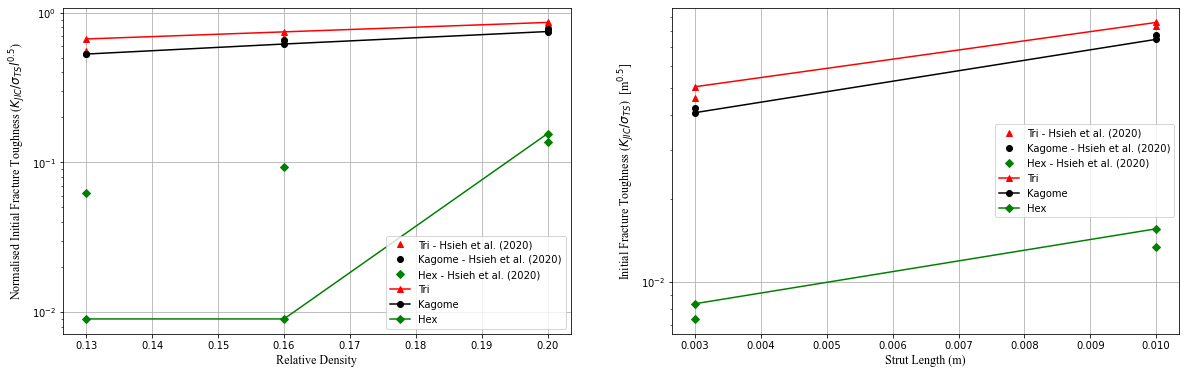

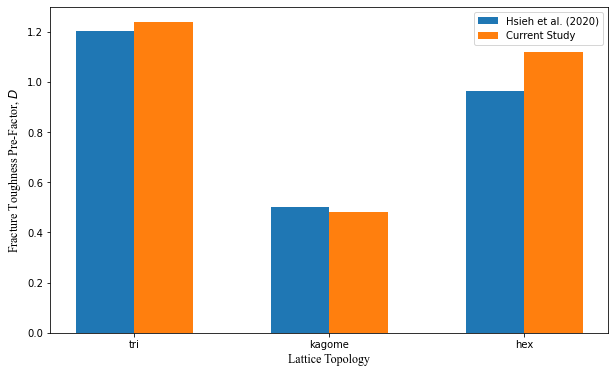

In [7]:
Deshpande1_df = pd.read_excel(researchData, sheet_name="Deshpande", header=12, nrows=18)
Deshpande2_df = pd.read_excel(researchData, sheet_name="Deshpande", header=35, nrows=6)
validation_df = pd.read_excel(researchData, sheet_name="Validation", header=41, nrows=40)


drop_cols = [i for i in Deshpande1_df.columns if "Unnamed" in i]
Deshpande1_df = Deshpande1_df.drop(columns=drop_cols)

triDesh1_df = Deshpande1_df[Deshpande1_df.lat == "tri"]
kagomeDesh1_df = Deshpande1_df[Deshpande1_df.lat == "kagome"]
hexDesh1_df = Deshpande1_df[Deshpande1_df.lat == "hex"]

triDesh1_10_df = triDesh1_df[triDesh1_df.strut_l == 0.01]
triDesh1_3_df = triDesh1_df[triDesh1_df.strut_l == 0.003]
kagomeDesh1_10_df = kagomeDesh1_df[kagomeDesh1_df.strut_l == 0.01]
kagomeDesh1_3_df = kagomeDesh1_df[kagomeDesh1_df.strut_l == 0.003]
hexDesh1_10_df = hexDesh1_df[hexDesh1_df.strut_l == 0.01]
hexDesh1_3_df = hexDesh1_df[hexDesh1_df.strut_l == 0.003]


drop_cols = [i for i in Deshpande2_df.columns if "Unnamed" in i]
Deshpande2_df = Deshpande2_df.drop(columns=drop_cols)

triDesh2_df = Deshpande2_df[Deshpande2_df.lat == "tri"]
kagomeDesh2_df = Deshpande2_df[Deshpande2_df.lat == "kagome"]
hexDesh2_df = Deshpande2_df[Deshpande2_df.lat == "hex"]

Desh2_10_df = Deshpande2_df[Deshpande2_df.strut_l == 0.01]


drop_cols = [i for i in validation_df.columns if "Unnamed" in i]
validation_df = validation_df.drop(columns=drop_cols)

triVal_df = validation_df[validation_df.lat == "tri"]
kagomeVal_df = validation_df[validation_df.lat == "kagome"]
hexVal_df = validation_df[validation_df.lat == "hex"]

triVal_10_df = triVal_df[(triVal_df.strut_l == 0.01) & (triVal_df.rel_d <= 0.2)]
triVal_3_df = triVal_df[(triVal_df.strut_l == 0.003) & (triVal_df.rel_d <= 0.2)]
kagomeVal_10_df = kagomeVal_df[(kagomeVal_df.strut_l == 0.01) & (kagomeVal_df.rel_d <= 0.2)]
kagomeVal_3_df = kagomeVal_df[(kagomeVal_df.strut_l == 0.003) & (kagomeVal_df.rel_d <= 0.2)]
hexVal_10_df = hexVal_df[(hexVal_df.strut_l == 0.01) & (hexVal_df.rel_d <= 0.2)]
hexVal_3_df = hexVal_df[(hexVal_df.strut_l == 0.003) & (hexVal_df.rel_d <= 0.2)]

triVal_02_df = triVal_df[triVal_df.rel_d == 0.2]
kagomeVal_02_df = kagomeVal_df[kagomeVal_df.rel_d == 0.2]
hexVal_02_df = hexVal_df[hexVal_df.rel_d == 0.2]

Val_10_02_df = validation_df[(validation_df.rel_d == 0.2) & (validation_df.strut_l == 0.01)]


fig5, (ax1, ax2) = plt.subplots(1, 2)
fig5.set_figheight(6)
fig5.set_figwidth(20)
#fig5.suptitle("Validation", fontsize=16, fontname="Times New Roman", fontweight='bold')

# ax1.set_title("Fracture Toughness", fontsize=14, fontname="Times New Roman", fontweight='bold')
ax1.set_ylabel('Normalised Initial Fracture Toughness ($K_{JIC}/\sigma_{TS}l^{0.5}$)', fontsize=12, fontname="Times New Roman")
ax1.set_xlabel('Relative Density', fontsize=12, fontname="Times New Roman")

ax1.plot(triDesh1_10_df.rel_d.tolist(), triDesh1_10_df["**Kjic/Sts*root_l"].tolist(), "r^",  label="Tri - Hsieh et al. (2020)")
# ax1.plot(triDesh1_3_df.rel_d.tolist(), triDesh1_3_df["**Kjic/Sts*root_l"].tolist(), "r^",  label="Tri 3 - Hsieh et al. (2020)")
ax1.plot(kagomeDesh1_10_df.rel_d.tolist(), kagomeDesh1_10_df["**Kjic/Sts*root_l"].tolist(), "ko",  label="Kagome - Hsieh et al. (2020)")
# ax1.plot(kagomeDesh1_3_df.rel_d.tolist(), kagomeDesh1_3_df["**Kjic/Sts*root_l"].tolist(), "ko",  label="Kagome 3 - Hsieh et al. (2020)")
ax1.plot(hexDesh1_10_df.rel_d.tolist(), hexDesh1_10_df["**Kjic/Sts*root_l"].tolist(), "gD",  label="Hex - Hsieh et al. (2020)")
# ax1.plot(hexDesh1_3_df.rel_d.tolist(), hexDesh1_3_df["**Kjic/Sts*root_l"].tolist(), "gD",  label="Hex 3 - Hsieh et al. (2020)")

ax1.plot(triVal_10_df.rel_d.tolist(), triVal_10_df["Kj1c/Sts*root_l"].tolist(), "r^-",  label="Tri")
ax1.plot(kagomeVal_10_df.rel_d.tolist(), kagomeVal_10_df["Kj1c/Sts*root_l"].tolist(), "ko-",  label="Kagome")
ax1.plot(hexVal_10_df.rel_d.tolist(), hexVal_10_df["Kj1c/Sts*root_l"].tolist(), "gD-",  label="Hex")

ax1.set_yscale("log")
ax1.grid()
ax1.legend()

#ax2.set_title("Fracture Toughness / UTS", fontsize=14, fontname="Times New Roman", fontweight='bold')
ax2.set_ylabel('Initial Fracture Toughness ($K_{JIC}/\sigma_{TS}$)  [m$^{0.5}$]', fontsize=12, fontname="Times New Roman")
ax2.set_xlabel('Strut Length (m)', fontsize=12, fontname="Times New Roman")

ax2.plot(triDesh2_df["strut_l"].tolist(), triDesh2_df["**Kjic/Sts"].tolist(), "r^",  label="Tri - Hsieh et al. (2020)")
ax2.plot(kagomeDesh2_df["strut_l"].tolist(), kagomeDesh2_df["**Kjic/Sts"].tolist(), "ko",  label="Kagome - Hsieh et al. (2020)")
ax2.plot(hexDesh2_df["strut_l"].tolist(), hexDesh2_df["**Kjic/Sts"].tolist(), "gD",  label="Hex - Hsieh et al. (2020)")

ax2.plot(triVal_02_df.strut_l.tolist(), triVal_02_df["Kj1c/Sts"].tolist(), "r^-", label="Tri")
ax2.plot(kagomeVal_02_df.strut_l.tolist(), kagomeVal_02_df["Kj1c/Sts"].tolist(), "ko-", label="Kagome")
ax2.plot(hexVal_02_df.strut_l.tolist(), hexVal_02_df["Kj1c/Sts"].tolist(), "gD-", label="Hex")

ax2.set_yscale("log")
ax2.grid()
ax2.legend()

fig6, (ax) = plt.subplots(1, 1)
fig6.set_figheight(6)
fig6.set_figwidth(10)

ax.set_ylabel('Fracture Toughness Pre-Factor, $D$', fontsize=12, fontname="Times New Roman")
ax.set_xlabel('Lattice Topology', fontsize=12, fontname="Times New Roman")

ax.bar(Desh2_10_df.lat.tolist(), Desh2_10_df.D.tolist(), width=-0.3, align="edge", label="Hsieh et al. (2020)")
ax.bar(Val_10_02_df.lat.tolist(), Val_10_02_df.D.tolist(), width=0.3, align="edge", label="Current Study")

ax.legend()

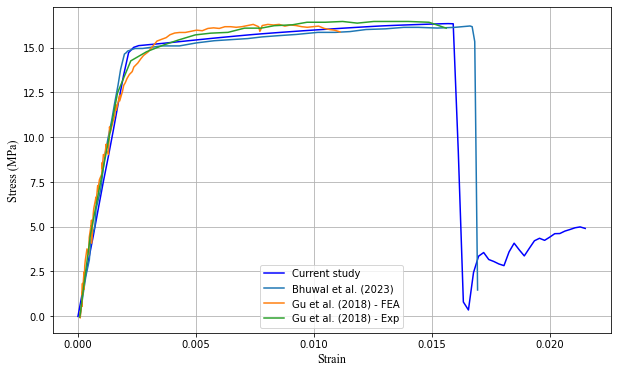

In [8]:
val_df     = pd.read_excel(researchData, sheet_name="UTval", names=[str(i) for i in range(20)])
current_df = val_df.loc[:, '0':'1'].rename(columns={'0':'strain', '1':'stress'})
s15        = val_df.loc[:, '3':'4'].rename(columns={'3':'strain', '4':'stress'})
s15_9711   = val_df.loc[:, '5':'6'].rename(columns={'5':'strain', '6':'stress'})
s18        = val_df.loc[:, '7':'8'].rename(columns={'7':'strain', '8':'stress'})
s18m10     = val_df.loc[:, '9':'10'].rename(columns={'9':'strain', '10':'stress'})
akash_df   = val_df.loc[:, '12':'13'].rename(columns={'12':'strain', '13':'stress'})
GuFEA_df   = val_df.loc[:, '15':'16'].rename(columns={'15':'strain', '16':'stress'})
GuEXP_df   = val_df.loc[:, '18':'19'].rename(columns={'18':'strain', '19':'stress'})

fig7, (ax1) = plt.subplots(1, 1)
fig7.set_figheight(6)
fig7.set_figwidth(10)

ax1.set_ylabel('Stress (MPa)', fontsize=12, fontname="Times New Roman")
ax1.set_xlabel('Strain', fontsize=12, fontname="Times New Roman")

ax1.plot(current_df.strain.tolist(), current_df.stress.tolist(), c='blue', label='Current study')
# ax1.plot(s15.strain.tolist(), s15.stress.tolist(), label='15')
# ax1.plot(s15_9711.strain.tolist(), s15_9711.stress.tolist(), label='15-9.7-1.1')
# ax1.plot(s18.strain.tolist(), s18.stress.tolist(), label='18')
# ax1.plot(s18m10.strain.tolist(), s18m10.stress.tolist(), label='18-10mesh')
ax1.plot(akash_df.strain.tolist(), akash_df.stress.tolist(), label='Bhuwal et al. (2023)')
ax1.plot(GuFEA_df.strain.tolist(), GuFEA_df.stress.tolist(), label='Gu et al. (2018) - FEA')
ax1.plot(GuEXP_df.strain.tolist(), GuEXP_df.stress.tolist(), label='Gu et al. (2018) - Exp')


ax1.grid()
ax1.legend()